#### Task 1: Build and Summarize Synthetic Datasets
Start by creating three synthetic datasets that represent different distribution shapes. Each dataset should have 500 observations.

1.**Dataset A** — Symmetric: draw from a normal distribution with mean = 50 and standard deviation = 10.

2.**Dataset B** — Right-skewed: draw from an exponential distribution, then shift and scale so the values fall roughly in the 0–100 range.

3.**Dataset C** — Bimodal: combine two normal distributions (e.g., means at 30 and 70) with equal sample sizes.
For each dataset, compute and display in a summary table:

- Mean, median, mode (rounded to 2 decimals)
  
- Standard deviation, variance, IQR

- Skewness and kurtosis (use scipy.stats.skew and scipy.stats.kurtosis)

Guiding question: Which summary statistics look similar across the three datasets, and which reveal the differences?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [3]:
n=500

#DatasetA
A=np.random.normal(loc=50,scale=10,size=n)
#DatasetB

B=np.random.exponential(scale=20,size=n)
B=(B/B.max())*100

#DatasetC
C1=np.random.normal(30,5,n//2)
C2 = np.random.normal(70, 5, n//2)
C = np.concatenate([C1, C2])

In [5]:
def summarize(data):
    return {
        "Mean": round(np.mean(data), 2),
        "Median": round(np.median(data), 2),
        "Mode": round(stats.mode(data, keepdims=True)[0][0], 2),
        "Std Dev": round(np.std(data), 2),
        "Variance": round(np.var(data), 2),
        "IQR": round(stats.iqr(data), 2),
        "Skewness": round(stats.skew(data), 2),
        "Kurtosis": round(stats.kurtosis(data), 2)
    }

summary = pd.DataFrame({
    "Dataset A": summarize(A),
    "Dataset B": summarize(B),
    "Dataset C": summarize(C)
})

summary

,Dataset A,Dataset B,Dataset C
Mean,50.62,16.62,50.33
Median,50.21,11.01,51.19
Mode,20.79,0.00,18.90
Std Dev,9.81,16.62,20.57
Variance,96.15,276.33,422.95
IQR,13.48,18.78,40.04
Skewness,-0.02,1.66,0.00
Kurtosis,-0.04,2.98,-1.80


**Answer (English):**

Some summary statistics such as the **mean, median, and standard deviation** may look similar across the three datasets because they measure the central tendency and spread of the data. However, these statistics alone do not fully describe the shape of the distribution.

The statistics that reveal the differences are **skewness, kurtosis, and the relationship between the mean and median**. For example, the **right-skewed dataset** has a positive skewness and the mean is usually larger than the median. The **bimodal dataset** may have a mean similar to the symmetric dataset, but it actually contains **two peaks**, which indicates two separate groups in the data. Therefore, skewness and kurtosis help identify differences in the distribution shapes.


#### Task 2: Visualize the Distributions
Create a figure with three rows and three columns (9 subplots total). Each row represents one dataset (A, B, C). The columns are:

1.**Histogram** with 30 bins and a KDE overlay.

2.**Boxplot** (horizontal orientation).

3,**KDE plot** alone, with vertical lines marking the mean (dashed red) and median (solid blue).

Add clear titles and axis labels to every subplot. Use plt.tight_layout() to prevent overlap.

Guiding question: For which dataset(s) do the mean and median diverge the most? What visual feature explains the divergence?

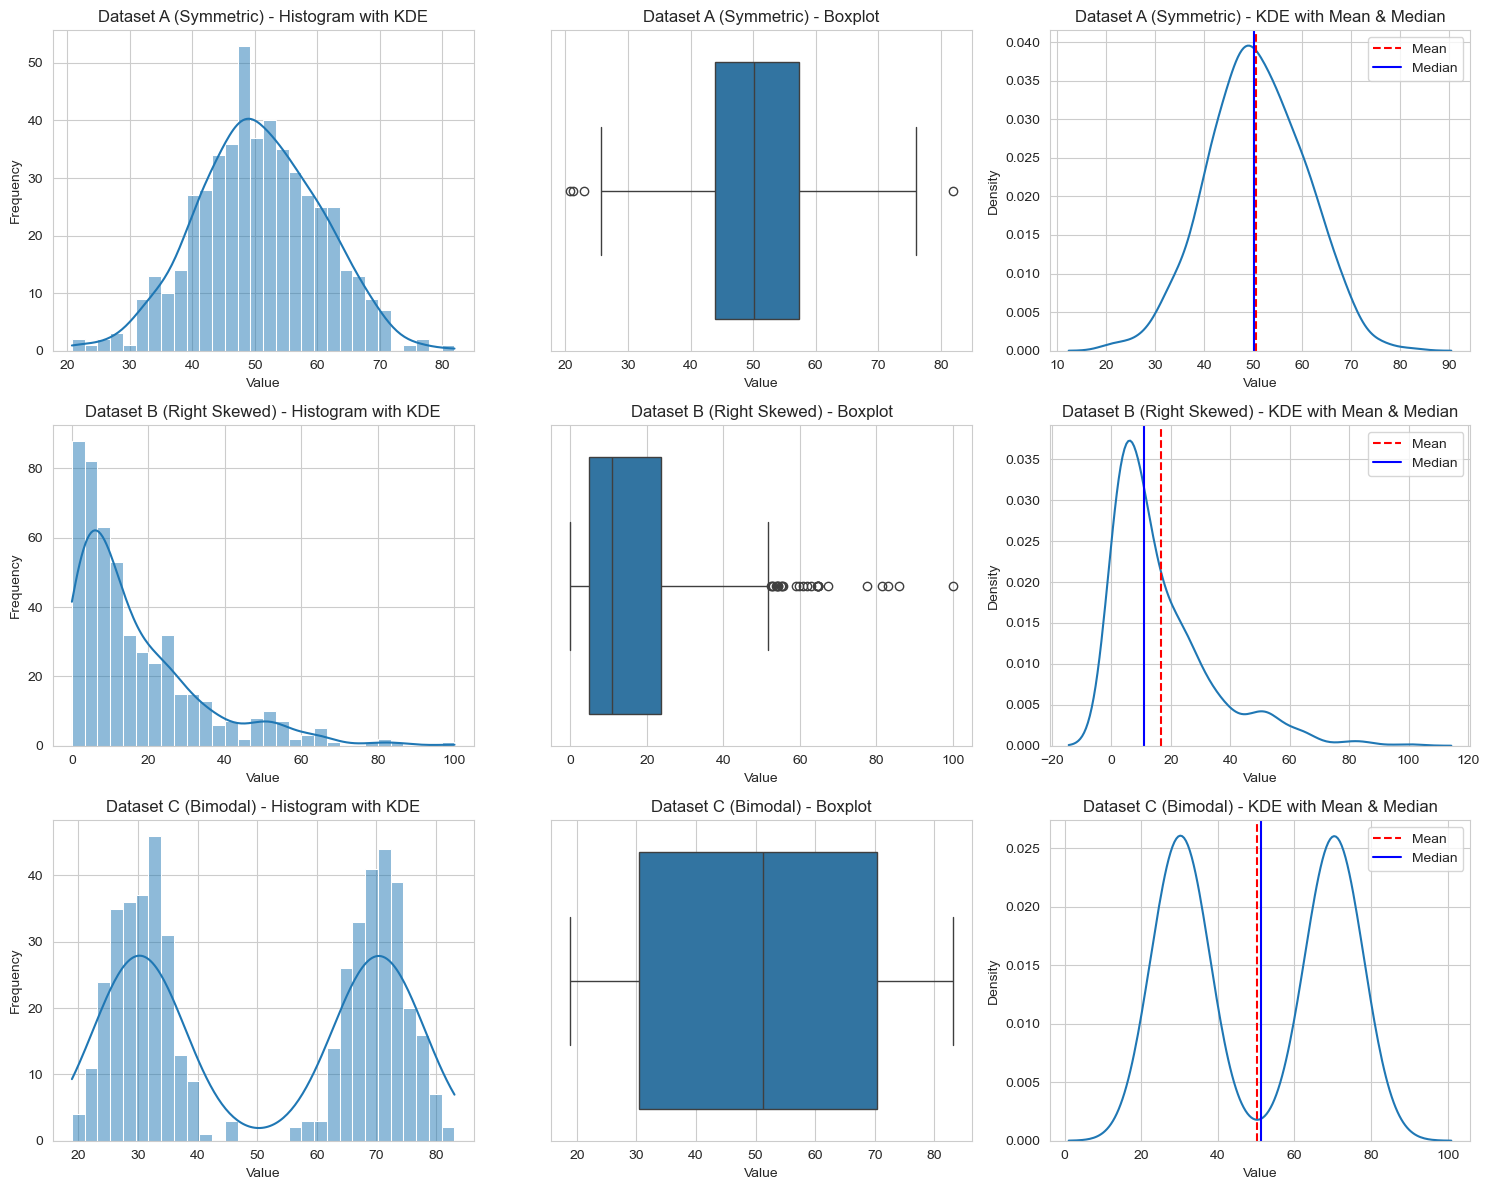

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

datasets = [A, B, C]
names = ["Dataset A (Symmetric)", "Dataset B (Right Skewed)", "Dataset C (Bimodal)"]

for i, data in enumerate(datasets):

    mean = np.mean(data)
    median = np.median(data)

    # Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i,0])
    axes[i,0].set_title(f"{names[i]} - Histogram with KDE")
    axes[i,0].set_xlabel("Value")
    axes[i,0].set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(x=data, ax=axes[i,1])
    axes[i,1].set_title(f"{names[i]} - Boxplot")
    axes[i,1].set_xlabel("Value")

    # KDE plot
    sns.kdeplot(data, ax=axes[i,2])

    axes[i,2].axvline(mean, color='red', linestyle='--', label='Mean')
    axes[i,2].axvline(median, color='blue', linestyle='-', label='Median')

    axes[i,2].set_title(f"{names[i]} - KDE with Mean & Median")
    axes[i,2].set_xlabel("Value")
    axes[i,2].set_ylabel("Density")
    axes[i,2].legend()

plt.tight_layout()
plt.show()

The mean and median diverge the most in Dataset B (right-skewed dataset). This happens because the distribution has a long tail on the right side, which pulls the mean toward larger values. As a result, the mean becomes larger than the median. The histogram and KDE plot clearly show this long right tail, explaining the difference between the two measures.

#### Task 3: The Outlier Stress Test
Take Dataset A (the symmetric one) and create a modified copy:

1.Replace the 5 largest values with extreme outliers: multiply each by 10.

2.Compute the same summary statistics table as Task 1 for both the original and modified versions.

3.Create side-by-side boxplots (original vs. modified) and overlay the mean as a diamond marker on each.

Answer the following in a markdown cell:

- Which statistics changed the most? Which were robust?

- If you were reporting a "typical" value for the modified dataset, would you choose the mean or the median? Why?

In [8]:
# Copy Dataset A
A_modified = A.copy()

# Find indices of the 5 largest values
largest_idx = np.argsort(A_modified)[-5:]

# Multiply them by 10 to create extreme outliers
A_modified[largest_idx] = A_modified[largest_idx] * 10

In [9]:
summary_outliers = pd.DataFrame({
    "Original Dataset A": summarize(A),
    "Modified Dataset A": summarize(A_modified)
})

summary_outliers

,Original Dataset A,Modified Dataset A
Mean,50.62,57.48
Median,50.21,50.21
Mode,20.79,20.79
Std Dev,9.81,71.54
Variance,96.15,5117.58
IQR,13.48,13.48
Skewness,-0.02,9.62
Kurtosis,-0.04,92.45


C:\Users\User\AppData\Local\Temp\ipykernel_19948\2753882221.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Original A", "Modified A"])


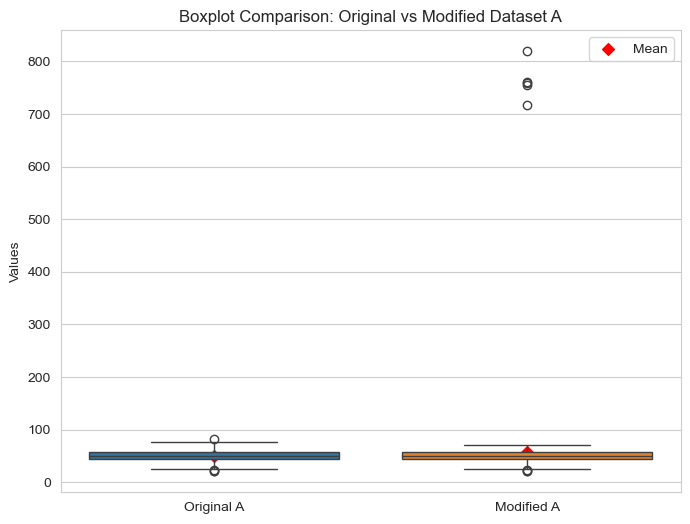

In [10]:
fig, ax = plt.subplots(figsize=(8,6))

data_to_plot = [A, A_modified]

sns.boxplot(data=data_to_plot, ax=ax)

# Means
means = [np.mean(A), np.mean(A_modified)]

# Overlay mean markers
ax.scatter([0,1], means, marker='D', color='red', label='Mean')

ax.set_xticklabels(["Original A", "Modified A"])
ax.set_title("Boxplot Comparison: Original vs Modified Dataset A")
ax.set_ylabel("Values")

ax.legend()

plt.show()

The statistics that changed the most were the mean, standard deviation, variance, skewness, and kurtosis. These measures are highly sensitive to extreme values, so the outliers significantly increased them.

The statistics that remained more stable were the median and IQR. These are considered robust statistics because they are less affected by extreme values.

If I had to report a typical value for the modified dataset, I would choose the median instead of the mean. The mean is heavily influenced by the extreme outliers, while the median still represents the central location of the majority of the data.